In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
file_name = r'cleaned_laptop_data.csv'
df=pd.read_csv(file_name)

In [4]:
df['brand'].value_counts()

brand
dell         1683
hp            768
rokc          637
lenovo        274
asus          154
acer          104
msi            67
lg             37
apple          22
samsung        18
alienware      13
panasonic      12
microsoft      11
gigabyte       11
toughbook      11
razer           4
latitude        3
Name: count, dtype: int64

In [5]:
y = df['price'] 
# X = 除了 price 以外全部
X = df.drop('price', axis=1)

In [6]:
#先進行資料拆分
#train 60 validate 20 test 20
#第一次分層
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=123, 
    stratify=df['brand']  )
#第二次分層
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    random_state=123, 
    stratify=X_temp['brand'] 

)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
def brand_percentage(df):
    # normalize=True 就是把「數量」換成「百分比」 (例如 0.2 就是 20%)
    # sort_index() 是讓品牌按字母排序 (A, B, C...)，這樣對比才整齊
    result=df['brand'].value_counts(normalize=True).sort_index()
    return result
train_per=brand_percentage(X_train)
val_per=brand_percentage(X_val)

comparison_table=pd.DataFrame({
    'Train(%)':train_per,
    'Validation(%)':val_per
})

print(comparison_table)


           Train(%)  Validation(%)
brand                             
acer       0.026992       0.027415
alienware  0.003483       0.002611
apple      0.006095       0.005222
asus       0.040052       0.040470
dell       0.439269       0.439948
gigabyte   0.003047       0.002611
hp         0.200261       0.201044
latitude   0.000871            NaN
lenovo     0.071397       0.071802
lg         0.009578       0.010444
microsoft  0.003047       0.002611
msi        0.017414       0.018277
panasonic  0.003483       0.002611
razer      0.000871       0.001305
rokc       0.166304       0.167102
samsung    0.004789       0.003916
toughbook  0.003047       0.002611


In [13]:
df.head()

,brand,model,screen_size,color,harddisk,cpu,ram(GB),OS,special_features,graphics,graphics_coprocessor,cpu_speed,rating,price,currency_symbol,harddisk_new_GB
0,rokc,NaN,14.0,Blue,1000 GB,Intel Core i7,8.0,Windows 11,NaN,Integrated,Intel,1.2 GHz,NaN,589.99,$,1000.0
1,hp,NaN,15.0,Silver,1000 GB,Intel Core i5,64.0,Windows 11 Pro,Backlit Keyboard,Integrated,Intel,NaN,4.5,999.99,$,1000.0
2,apple,MacBook Air,13.0,Silver,256 GB,Unknown,8.0,Mac OS,Backlit Keyboard,Integrated,NaN,NaN,4.8,689.99,$,256.0
3,apple,MacBook Air,15.0,Midnight,256 GB,Unknown,8.0,Mac OS,NaN,Integrated,NaN,NaN,4.8,1144.48,$,256.0
4,acer,A315-24P-R7VH,15.0,Silver,128 GB,Ryzen 3,8.0,Windows 11 S,Backlit Keyboard,Integrated,NaN,NaN,4.5,299.99,$,128.0


先取'ram(GB)', 'harddisk_new_GB', 'screen_size','brand'
跑Baseline 和 RandomForest模型

In [8]:
numeric_features = ['ram(GB)', 'harddisk_new_GB', 'screen_size']
categorical_features = ['brand']

X_train_model = X_train[numeric_features + categorical_features].copy()
X_val_model = X_val[numeric_features + categorical_features].copy()
X_test_model = X_test[numeric_features + categorical_features].copy()

##### 數值欄位：補缺失值 + 標準化
##### 類別欄位：補缺失值 + one-hot encoding


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


baseline_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression())
])
#訓練模型
baseline_model.fit(X_train_model, y_train)


In [23]:
#驗證
val_predict_baseline=baseline_model.predict(X_val_model)
baseline_mae = mean_absolute_error(y_val, val_predict_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_val, val_predict_baseline))
baseline_r2 = r2_score(y_val, val_predict_baseline)


print("Baseline Linear Regression")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2:", baseline_r2)

Baseline Linear Regression
MAE: 443.70957514390255
RMSE: 597.7752605056598
R2: 0.4169148511330134


### Random Forest (rf_model)

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

rf_model.fit(X_train_model, y_train)

val_pred_rf = rf_model.predict(X_val_model)

rf_mae = mean_absolute_error(y_val, val_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_val, val_pred_rf))
rf_r2 = r2_score(y_val, val_pred_rf)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
MAE: 291.75792669743123
RMSE: 502.6601962159042
R2: 0.5877078193885543


比較 BASELINE跟RANDOMFOREST

本專案先建立 Linear Regression 作為 baseline model，其在 validation set 上的 MAE 為 443.71、RMSE 為 597.78、R² 為 0.4169。接著使用 Random Forest 捕捉筆電規格與價格之間的非線性關係，模型表現提升至 MAE 291.76、RMSE 502.66、R² 0.5877。相較於 baseline model，Random Forest 的 MAE 約下降 34.2%


In [ ]:

model_results = pd.DataFrame({
    'model': ['Linear Regression', 'Random Forest'],
    'MAE': [baseline_mae, rf_mae],
    'RMSE': [baseline_rmse, rf_rmse],
    'R2': [baseline_r2, rf_r2]
})

model_results

,model,MAE,RMSE,R2
0,Linear Regression,443.709575,597.775261,0.416915
1,Random Forest,291.757927,502.660196,0.587708



現有結構化規格能解釋一部分價格差異，但仍有許多價格因素未被資料集完整捕捉，因此後續若要提升模型解釋力，需要補充 CPU/GPU 等更細緻特徵。
雖然模型 R² 約 0.588，屬於中等解釋力，但仍可以用 feature importance 做方向性分析，觀察目前資料中哪些特徵對價格預測最有貢獻。不過這不是因果結論。

Q2 feature importance

In [29]:
feature_names = rf_model.named_steps['preprocess'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

feature_importance = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    .sort_values('importance', ascending=False)
)

feature_importance.head(20)



,feature,importance
2,num__screen_size,0.343428
0,num__ram(GB),0.265739
1,num__harddisk_new_GB,0.188999
7,cat__brand_dell,0.099728
9,cat__brand_hp,0.032302
17,cat__brand_rokc,0.013921
6,cat__brand_asus,0.009106
14,cat__brand_msi,0.007922
16,cat__brand_razer,0.007515
5,cat__brand_apple,0.007202


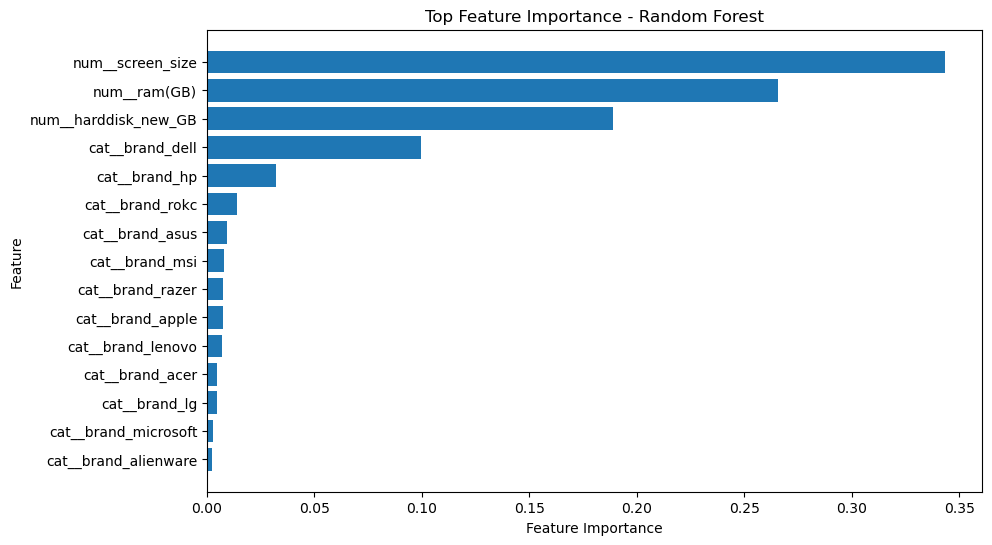

In [30]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top Feature Importance - Random Forest')
plt.show()

本專案使用 Random Forest 進行特徵重要性分析。由於品牌欄位經過 one-hot encoding，因此原本的 brand 會被展開成多個品牌特徵，例如 brand_dell、brand_hp、brand_asus 等。結果顯示，模型主要依賴螢幕大小、RAM、硬碟容量與品牌相關特徵來預測筆電價格。其中螢幕大小的重要性最高，可能是因為它在資料集中間接反映了筆電類型，例如電競筆電或工作站筆電。不過，feature importance 反映的是模型決策時的相對貢獻，不能直接解讀為因果關係。

In [31]:
feature_importance_grouped = feature_importance.copy()

feature_importance_grouped['original_feature'] = (
    feature_importance_grouped['feature']
    .str.replace('num__', '', regex=False)
    .str.replace(r'cat__brand_.*', 'brand', regex=True)
)

feature_importance_grouped = (
    feature_importance_grouped
    .groupby('original_feature', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
)

feature_importance_grouped

,original_feature,importance
3,screen_size,0.343428
2,ram(GB),0.265739
0,brand,0.201833
1,harddisk_new_GB,0.188999


Q3：哪些品牌有品牌溢價？

接下來做 residual analysis：

residual = actual price - predicted price

In [33]:
test_pred_rf = rf_model.predict(X_test_model)

test_result = X_test_model.copy()
test_result["actual_price"] = y_test.values
test_result["predicted_price"] = test_pred_rf
test_result["residual"] = test_result["actual_price"] - test_result["predicted_price"]

brand_premium = (
    test_result
    .groupby("brand")
    .agg(
        avg_actual_price=("actual_price", "mean"),
        avg_predicted_price=("predicted_price", "mean"),
        avg_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        sample_count=("residual", "count")
    )
    .reset_index()
    .sort_values("avg_residual", ascending=False)
)

brand_premium

,brand,avg_actual_price,avg_predicted_price,avg_residual,median_residual,sample_count
13,razer,2699.990000,1202.514496,1497.475504,1.497476e+03,1
5,gigabyte,2824.495000,2411.441518,413.053482,4.130535e+02,2
12,panasonic,1216.465000,896.021825,320.443175,3.204432e+02,2
15,samsung,1020.820000,749.570436,271.249564,5.189894e+01,4
4,dell,1502.738131,1448.179015,54.559115,-4.661237e+01,337
2,apple,1906.250000,1876.577319,29.672681,-1.471761e+02,4
14,rokc,537.470315,539.620884,-2.150569,6.821210e-13,127
11,msi,1957.233077,1966.097876,-8.864800,-2.333755e+02,13
8,lenovo,1168.198545,1184.020154,-15.821609,-2.190544e+01,55
3,asus,1422.216452,1438.184869,-15.968417,-1.086427e+01,31


In [ ]:
brand_premium_filtered = brand_premium[brand_premium["sample_count"] >= 3]
brand_premium_filtered

,brand,avg_actual_price,avg_predicted_price,avg_residual,median_residual,sample_count
15,samsung,1020.820000,749.570436,271.249564,5.189894e+01,4
4,dell,1502.738131,1448.179015,54.559115,-4.661237e+01,337
2,apple,1906.250000,1876.577319,29.672681,-1.471761e+02,4
14,rokc,537.470315,539.620884,-2.150569,6.821210e-13,127
11,msi,1957.233077,1966.097876,-8.864800,-2.333755e+02,13
8,lenovo,1168.198545,1184.020154,-15.821609,-2.190544e+01,55
3,asus,1422.216452,1438.184869,-15.968417,-1.086427e+01,31
6,hp,798.341883,836.412910,-38.071027,-1.762146e-12,154
9,lg,1330.667143,1414.158235,-83.491092,-2.968151e+01,7
0,acer,744.582857,955.481053,-210.898196,-5.859516e+01,21


Q3-B：品牌溢價版本
先只用硬體規格預測合理價格，再用 residual 比較不同品牌的實際價格差異。
我用 residual analysis，不直接比較品牌平均價格。因為品牌平均價格會受到規格不同影響，所以我先用模型預測合理價格，再看實際價格和預測價格的差距。由於有些品牌樣本數太少，我只解讀樣本數足夠的品牌。在目前結果中，Dell 的平均 residual 為正，代表實際價格略高於模型預測；Acer 則為負，代表實際價格低於模型預測。不過因為這版模型已經包含 brand 特徵，所以這比較像模型未解釋的價格偏差。若要更精準估計品牌溢價，我會再建立一個不含 brand 的模型，只用硬體規格預測價格，再用 residual 比較品牌差異。

In [37]:
# Q3-specific model: exclude brand to estimate brand premium
numeric_features_q3 = ['ram(GB)', 'harddisk_new_GB', 'screen_size']
categorical_features_q3 = []

X_train_q3 = X_train[numeric_features_q3].copy()
X_test_q3 = X_test[numeric_features_q3].copy()

q3_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

q3_preprocess = ColumnTransformer(
    transformers=[
        ('num', q3_numeric_transformer, numeric_features_q3)
    ]
)

q3_model = Pipeline(steps=[
    ('preprocess', q3_preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

q3_model.fit(X_train_q3, y_train)

q3_test_pred = q3_model.predict(X_test_q3)

q3_result = X_test.copy()
q3_result["actual_price"] = y_test.values
q3_result["predicted_price"] = q3_test_pred
q3_result["residual"] = q3_result["actual_price"] - q3_result["predicted_price"]

q3_brand_premium = (
    q3_result
    .groupby("brand")
    .agg(
        avg_actual_price=("actual_price", "mean"),
        avg_predicted_price=("predicted_price", "mean"),
        avg_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        sample_count=("residual", "count")
    )
    .reset_index()
    .sort_values("avg_residual", ascending=False)
)

q3_brand_premium_filtered = q3_brand_premium[q3_brand_premium["sample_count"] >= 3]

q3_brand_premium_filtered

,brand,avg_actual_price,avg_predicted_price,avg_residual,median_residual,sample_count
2,apple,1906.250000,1611.886782,294.363218,3.123539e+02,4
15,samsung,1020.820000,796.979089,223.840911,3.467528e+01,4
3,asus,1422.216452,1268.661109,153.555343,-1.870143e+01,31
4,dell,1502.738131,1403.600654,99.137476,-4.661237e+01,337
11,msi,1957.233077,1879.424398,77.808679,-9.634925e+01,13
8,lenovo,1168.198545,1170.279837,-2.081292,-2.922353e+01,55
14,rokc,537.470315,544.047128,-6.576813,-1.932676e-12,127
9,lg,1330.667143,1475.036415,-144.369272,3.262827e+01,7
6,hp,798.341883,946.927561,-148.585678,-9.965139e+01,154
1,alienware,1631.300000,1859.145728,-227.845728,1.128678e+02,3


結果顯示，在樣本數足夠的品牌中，ASUS、Dell、MSI 的平均 residual 為正，代表可能存在部分高價產品線或品牌定位效果。不過它們的 median residual 是負的，表示這種溢價並不是每個產品都穩定存在，可能是由少數高價機種拉高平均值。相對地，HP 和 Acer 的平均與中位 residual 都為負，代表它們在這份資料集中更偏向價格競爭或高 CP 值定位。

| brand  | avg_residual | median_residual | sample_count | 解讀                       |
| ------ | -----------: | --------------: | -----------: | ------------------------ |
| asus   |      +153.56 |          -18.70 |           31 | 平均值偏高，但中位數略低，可能由少數高價產品拉高 |
| dell   |       +99.14 |          -46.61 |          337 | 平均值略高，但典型產品未必有明顯溢價       |
| msi    |       +77.81 |          -96.35 |           13 | 平均值偏高，但樣本較少且中位數為負        |
| lenovo |        -2.08 |          -29.22 |           55 | 接近模型預測，價格定位中性            |
| rokc   |        -6.58 |            0.00 |          127 | 接近模型預測                   |
| hp     |      -148.59 |          -99.65 |          154 | 實際價格低於模型預測，偏價格競爭         |
| acer   |      -273.91 |         -186.03 |           21 | 明顯低於模型預測，可能偏入門或高 CP 定位   |


Q4 若調整某些規格，產品的價格帶是否會改變？其影響幅度多大？

In [38]:
def assign_price_band(price):
    if price < 500:
        return "Low"
    elif price < 1000:
        return "Mid"
    elif price < 1500:
        return "High"
    else:
        return "Premium"

In [40]:
what_if_cases = pd.DataFrame([
    {'brand': 'dell', 'ram(GB)': 8,  'harddisk_new_GB': 256,  'screen_size': 15.6},
    {'brand': 'dell', 'ram(GB)': 16, 'harddisk_new_GB': 512,  'screen_size': 15.6},
    {'brand': 'dell', 'ram(GB)': 32, 'harddisk_new_GB': 1024, 'screen_size': 15.6},
])

what_if_cases['predicted_price'] = rf_model.predict(what_if_cases)
what_if_cases['price_band'] = what_if_cases['predicted_price'].apply(assign_price_band)

what_if_cases

,brand,ram(GB),harddisk_new_GB,screen_size,predicted_price,price_band
0,dell,8,256,15.6,592.698334,Mid
1,dell,16,512,15.6,1308.992152,High
2,dell,32,1024,15.6,1923.026846,Premium


In [41]:
base_price = what_if_cases.loc[0, 'predicted_price']

what_if_cases['price_change_vs_base'] = (
    what_if_cases['predicted_price'] - base_price
)

what_if_cases['price_change_pct_vs_base'] = (
    what_if_cases['price_change_vs_base'] / base_price * 100
)

what_if_cases

,brand,ram(GB),harddisk_new_GB,screen_size,predicted_price,price_band,price_change_vs_base,price_change_pct_vs_base
0,dell,8,256,15.6,592.698334,Mid,0.000000,0.000000
1,dell,16,512,15.6,1308.992152,High,716.293818,120.853017
2,dell,32,1024,15.6,1923.026846,Premium,1330.328512,224.452885


In [42]:
brand_scenarios = pd.DataFrame([
    {'brand': 'dell',   'ram(GB)': 16, 'harddisk_new_GB': 512, 'screen_size': 15.6},
    {'brand': 'hp',     'ram(GB)': 16, 'harddisk_new_GB': 512, 'screen_size': 15.6},
    {'brand': 'asus',   'ram(GB)': 16, 'harddisk_new_GB': 512, 'screen_size': 15.6},
    {'brand': 'lenovo', 'ram(GB)': 16, 'harddisk_new_GB': 512, 'screen_size': 15.6},
    {'brand': 'acer',   'ram(GB)': 16, 'harddisk_new_GB': 512, 'screen_size': 15.6},
])

brand_scenarios['predicted_price'] = rf_model.predict(brand_scenarios)
brand_scenarios['price_band'] = brand_scenarios['predicted_price'].apply(assign_price_band)

brand_scenarios.sort_values('predicted_price', ascending=False)

,brand,ram(GB),harddisk_new_GB,screen_size,predicted_price,price_band
3,lenovo,16,512,15.6,1715.521730,Premium
1,hp,16,512,15.6,1657.144018,Premium
2,asus,16,512,15.6,1570.287309,Premium
4,acer,16,512,15.6,1372.311448,High
0,dell,16,512,15.6,1308.992152,High
